## C0 classifier - new custom split
#### For effusion prediction (homemade version)

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os

In [ ]:
DATA_DIR = "/zhome/d0/a/221493/thesis/data/"

In [ ]:
# Take the original train set
original_train = pd.read_csv(os.path.join(DATA_DIR, "CheXpert-v1.0-small/train.csv"))
print(f"Original train set shape: {original_train.shape}")

Original train set shape: (223414, 19)


In [ ]:
original_train

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223409,CheXpert-v1.0-small/train/patient64537/study2/...,Male,59,Frontal,AP,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,-1.0,0.0,1.0,NaN,NaN,NaN
223410,CheXpert-v1.0-small/train/patient64537/study1/...,Male,59,Frontal,AP,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,0.0,-1.0,NaN,-1.0,NaN,NaN,NaN
223411,CheXpert-v1.0-small/train/patient64538/study1/...,Female,0,Frontal,AP,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223412,CheXpert-v1.0-small/train/patient64539/study1/...,Female,0,Frontal,AP,NaN,NaN,1.0,1.0,NaN,NaN,NaN,-1.0,1.0,0.0,NaN,NaN,NaN,0.0


In [ ]:
# Split train into 50/50 for training and validation
train_df = original_train.sample(frac=0.5, random_state=42)
val_df = original_train.drop(train_df.index)
print(f"Train set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")

Train set shape: (111707, 19)
Validation set shape: (111707, 19)


Effusion distribution in training set:
Pleural Effusion
 1.0    43066
 0.0    17570
-1.0     5832
Name: count, dtype: int64
Effusion distribution in validation set:
Pleural Effusion
 1.0    43121
 0.0    17826
-1.0     5796
Name: count, dtype: int64


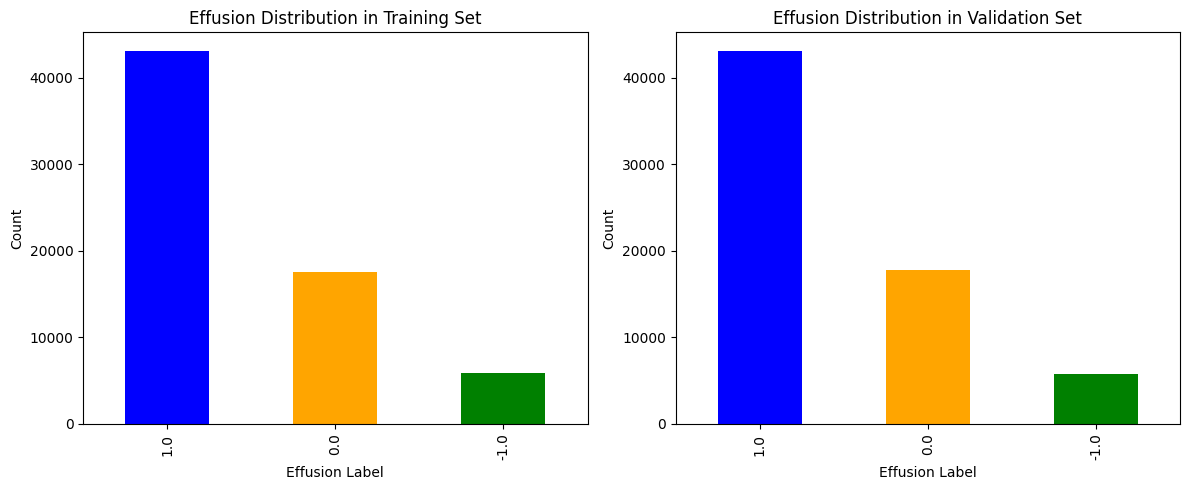

In [ ]:
# Look at the distribution of the target variable (Effusion) in the training set
train_effusion_count = train_df["Pleural Effusion"].value_counts()
print("Effusion distribution in training set:")
print(train_effusion_count)

valid_effusion_count = val_df["Pleural Effusion"].value_counts()
print("Effusion distribution in validation set:")
print(valid_effusion_count)

# Plot the distribution of the target variable in the training set and validation set (differen colors)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
train_effusion_count.plot(kind="bar", color=["blue", "orange", "green"])
plt.title("Effusion Distribution in Training Set")
plt.xlabel("Effusion Label")
plt.ylabel("Count")
plt.subplot(1, 2, 2)
valid_effusion_count.plot(kind="bar", color=["blue", "orange", "green"])
plt.title("Effusion Distribution in Validation Set")
plt.xlabel("Effusion Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Effusion distribution in training set after replacing -1 with 0:
Pleural Effusion
1.0    43066
0.0    23402
Name: count, dtype: int64
Effusion distribution in validation set after replacing -1 with 0:
Pleural Effusion
1.0    43121
0.0    23622
Name: count, dtype: int64


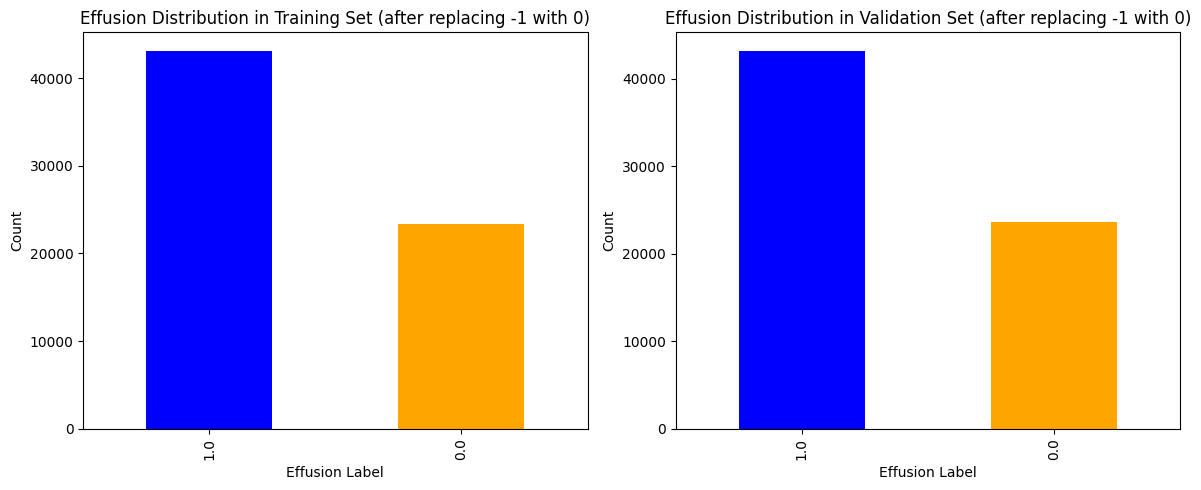

In [ ]:
# Make -1 (uncertain) into 0 (negative) for both training and validation sets
train_df["Pleural Effusion"] = train_df["Pleural Effusion"].replace(-1, 0)
val_df["Pleural Effusion"] = val_df["Pleural Effusion"].replace(-1, 0)

# Check the distribution again after replacing -1 with 0
train_effusion_count = train_df["Pleural Effusion"].value_counts()
print("Effusion distribution in training set after replacing -1 with 0:")
print(train_effusion_count)
valid_effusion_count = val_df["Pleural Effusion"].value_counts()
print("Effusion distribution in validation set after replacing -1 with 0:")
print(valid_effusion_count)

# Plot the distribution of the target variable in the training set and validation set after replacing -1 with 0 (different colors)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
train_effusion_count.plot(kind="bar", color=["blue", "orange"])
plt.title("Effusion Distribution in Training Set (after replacing -1 with 0)")
plt.xlabel("Effusion Label")
plt.ylabel("Count")
plt.subplot(1, 2, 2)
valid_effusion_count.plot(kind="bar", color=["blue", "orange"])
plt.title("Effusion Distribution in Validation Set (after replacing -1 with 0)")
plt.xlabel("Effusion Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

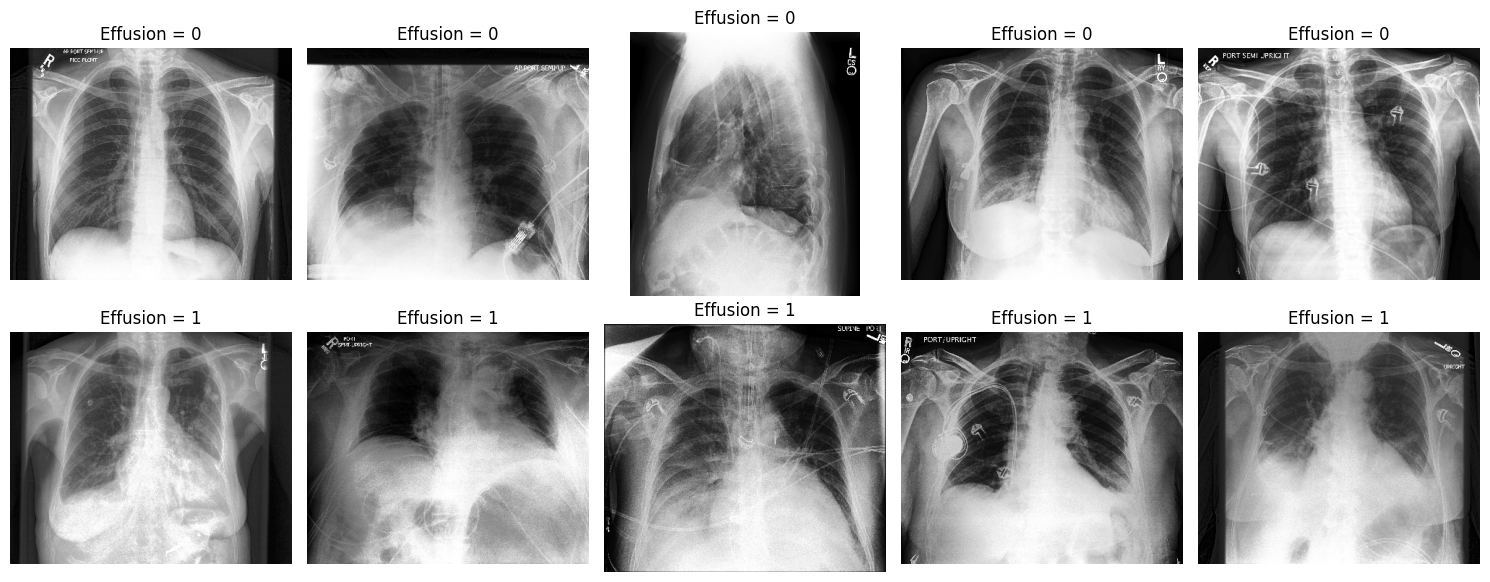

In [ ]:
# Visualize sample images from the training set for both classes (Effusion = 0 and Effusion = 1)
effusion_0_samples = train_df[train_df["Pleural Effusion"] == 0].sample(5, random_state=42)
effusion_1_samples = train_df[train_df["Pleural Effusion"] == 1].sample(5, random_state=42)
plt.figure(figsize=(15, 6))
for i, (index, row) in enumerate(effusion_0_samples.iterrows()):
    img_path = os.path.join(DATA_DIR, row["Path"])
    img = plt.imread(img_path)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("Effusion = 0")
    plt.axis("off")
for i, (index, row) in enumerate(effusion_1_samples.iterrows()):
    img_path = os.path.join(DATA_DIR, row["Path"])
    img = plt.imread(img_path)
    plt.subplot(2, 5, i + 6)
    plt.imshow(img, cmap="gray")
    plt.title("Effusion = 1")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Print size of both training and validation sets
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

Training set size: 111707
Validation set size: 111707


In [ ]:
# Save to CSV
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)

# Print sizes (your existing code)
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

In [ ]:
import os

train_path = os.path.join(DATA_DIR, "train.csv")
val_path = os.path.join(DATA_DIR, "val.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)